In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
import joblib

from skimage.io import imread
from skimage.transform import resize

import tensorflow as tf

In [4]:
model3 = tf.keras.models.load_model("model3_cnn_tensor.keras")
y_scaler = joblib.load("model3_y_scaler.pkl")

In [5]:
def predict_tensor_from_image(image_path, model, y_scaler, img_size=64):
    img = imread(image_path, as_gray=True)
    img_resized = resize(img, (img_size, img_size))

    X_single = np.array(img_resized, dtype=np.float32)
    X_single = X_single.reshape(1, img_size, img_size, 1)

    pred_scaled = model.predict(X_single)
    pred = y_scaler.inverse_transform(pred_scaled)

    return pred[0], img_resized

In [7]:
image_path = r"C:\Users\pkwki\OneDrive\Desktop\459 Project\data\fiber_subset\0.0191,0.4993,0.4816.jpg"

pred_tensor, img = predict_tensor_from_image(
    image_path,
    model3,
    y_scaler
)

print("Predicted orientation tensor:")
print("a_xx =", pred_tensor[0])
print("a_yy =", pred_tensor[1])
print("a_zz =", pred_tensor[2])
print("Sum =", pred_tensor.sum())

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
Predicted orientation tensor:
a_xx = 0.022714155
a_yy = 0.48977858
a_zz = 0.48741704
Sum = 0.99990976


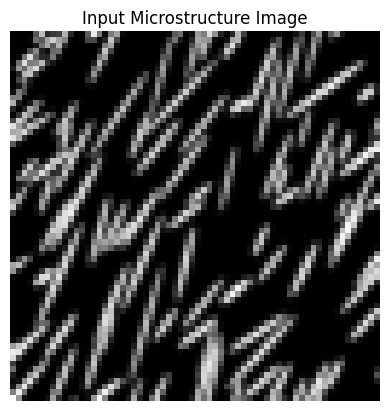

In [8]:
plt.imshow(img, cmap="gray")
plt.axis("off")
plt.title("Input Microstructure Image")
plt.show()

In [9]:
filename = os.path.basename(image_path).replace(".jpg", "")
true_tensor = np.array(list(map(float, filename.split(","))))

print("True tensor:")
print("a_xx =", true_tensor[0])
print("a_yy =", true_tensor[1])
print("a_zz =", true_tensor[2])

print("Prediction error:")
print(pred_tensor - true_tensor)

True tensor:
a_xx = 0.0191
a_yy = 0.4993
a_zz = 0.4816
Prediction error:
[ 0.00361415 -0.00952142  0.00581704]
